<a href="https://colab.research.google.com/github/Optimus0205/Data_Science_Project/blob/main/Outlier_Detection_and_Removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
pd.set_option('display.max_columns',None)

In [100]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv').drop_duplicates()
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,10.0,NaN,Relatively New,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,6.0,East,Relatively New,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110


In [101]:
df.shape

(3389, 23)

In [102]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

### 1. price

/tmp/ipykernel_2530/2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

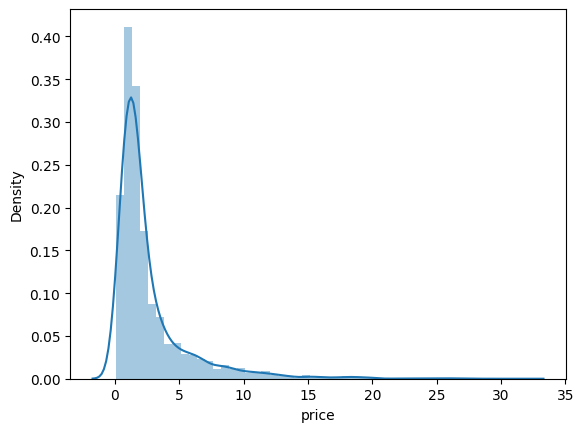

In [103]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

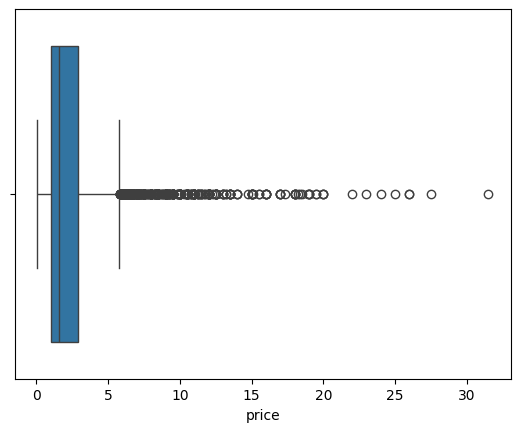

In [104]:
sns.boxplot(x=df['price'])

In [105]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(374,
 count    374.000000
 mean       9.700481
 std        4.106568
 min        5.800000
 25%        6.750000
 50%        8.490000
 75%       11.000000
 max       31.500000
 Name: price, dtype: float64)

In [106]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3205,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,9000.0,NaN,1,1,1,1,0,2,74
509,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
1235,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,1,138
2503,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
1745,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
699,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122
2546,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,1,145
898,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,54
2424,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,1,153
3451,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97


In [107]:
outliers.to_csv('outliers_price.csv',index=False)

In [108]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### 2. Price_per_sqft

/tmp/ipykernel_2530/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

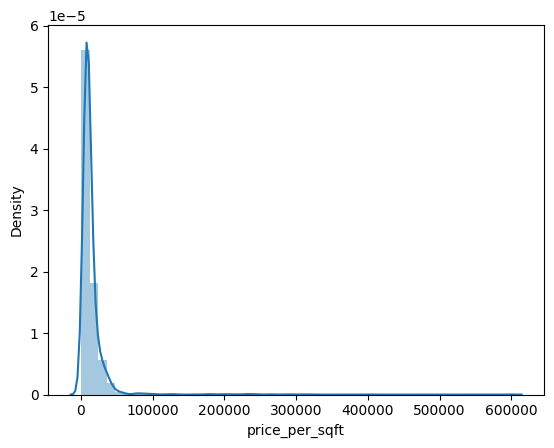

In [109]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

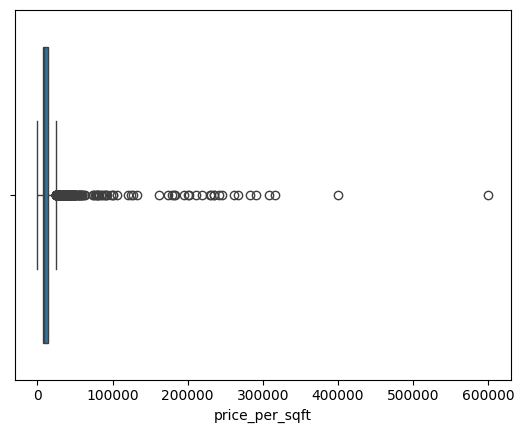

In [110]:
sns.boxplot(x=df['price_per_sqft'])

In [111]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(339,
 count       339.000000
 mean      53602.587021
 std       62263.172158
 min       24845.000000
 25%       28728.000000
 50%       33951.000000
 75%       42124.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [112]:
outliers_sqft.to_csv('outliers_price_per_sqft.csv',index=False)

At some place less than 1000 are in sq yard multiplying it with 9 so converting into sqft

In [113]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

/tmp/ipykernel_2530/205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [114]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

/tmp/ipykernel_2530/3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [115]:
outliers_sqft['price_per_sqft'].describe()

,price_per_sqft
count,339.000000
mean,29535.150442
std,12397.544042
min,2778.000000
25%,25963.000000
50%,30180.000000
75%,36111.000000
max,82540.000000


In [116]:
df.update(outliers_sqft)

/tmp/ipykernel_2530/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

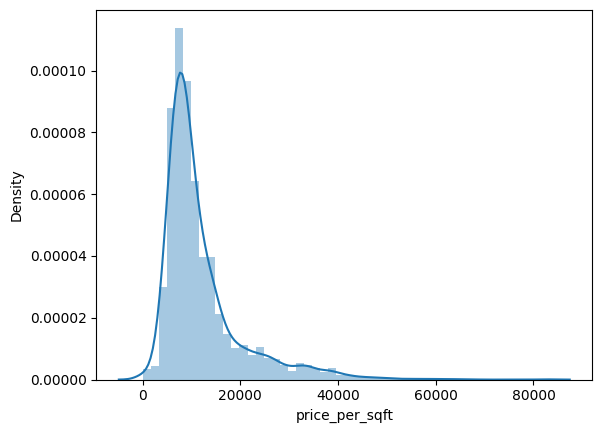

In [117]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

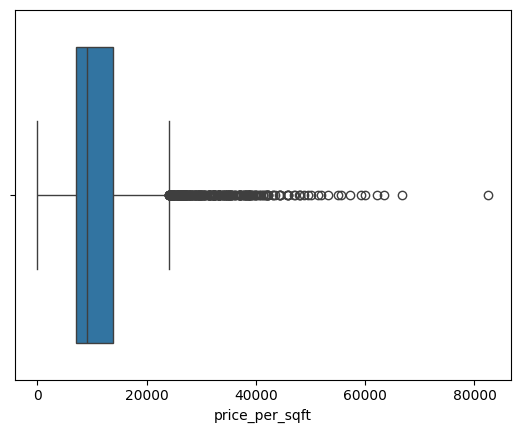

In [118]:
sns.boxplot(x=df['price_per_sqft'])

In [119]:
df[df['price_per_sqft']>50000].shape

(12, 23)

In [120]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

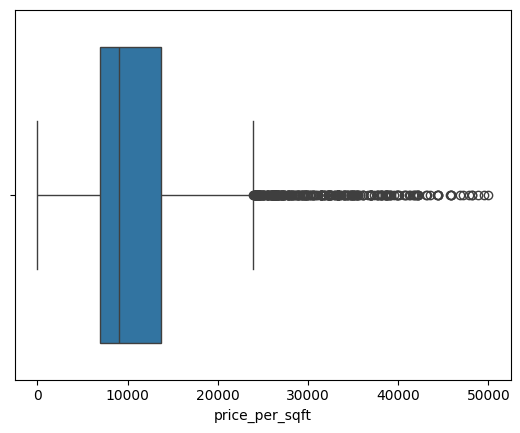

In [121]:
sns.boxplot(x=df['price_per_sqft'])

### 3. area

/tmp/ipykernel_2530/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

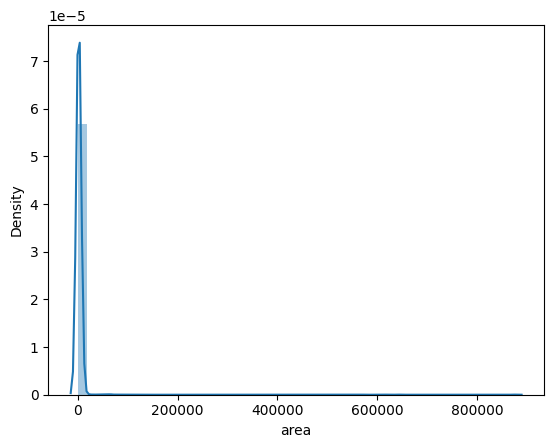

In [122]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

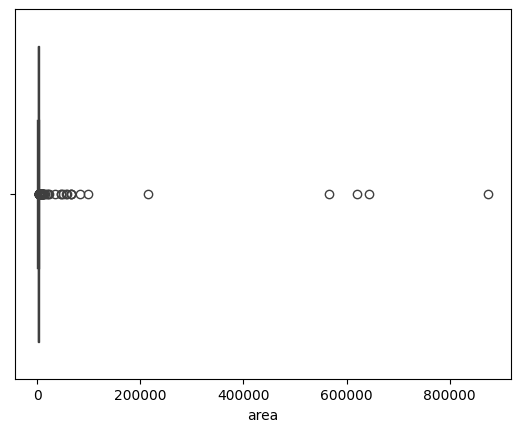

In [123]:
sns.boxplot(x=df['area'])

In [124]:
df['area'].describe()

,area
count,3360.000000
mean,3073.260714
std,24173.320573
min,145.000000
25%,1300.000000
50%,1784.500000
75%,2367.000000
max,875000.000000


In [125]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
815,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76
2794,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,65
3193,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44
3254,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
3273,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,1,0


In [126]:
df = df[df['area'] < 100000]

/tmp/ipykernel_2530/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

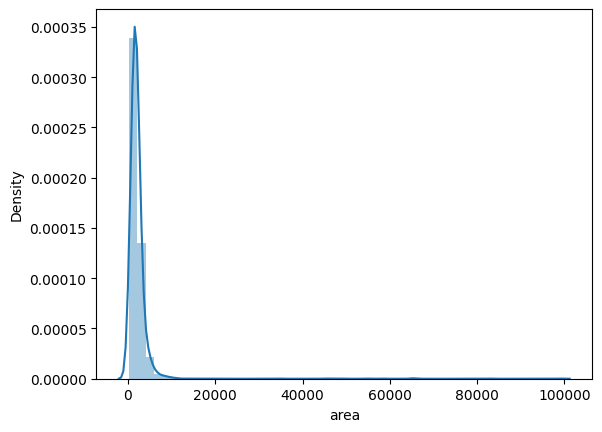

In [127]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

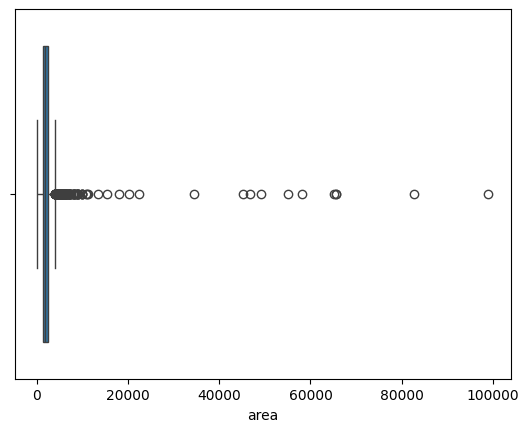

In [128]:
sns.boxplot(x=df['area'])

In [129]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 2495, 1307, 1213, 467, 1954, 1662, 831, 165, 2482

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2495,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,1,60
3191,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
1307,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.0,0,0,0,0,0,0,51
1213,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.0,1,0,0,0,0,0,15
2397,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.0,0,0,0,0,0,0,0
467,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
1954,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,0,37
1662,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,0,37
2446,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.0,0,1,1,0,0,1,109
831,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.0,0,0,0,0,1,0,33


In [130]:
df.loc[[2495, 1307, 1213, 467, 1954, 1662, 831, 165, 2482]]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2495,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,1,60
1307,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.0,0,0,0,0,0,0,51
1213,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.0,1,0,0,0,0,0,15
467,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0,0,0,0,0,0,15
1954,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,0,37
1662,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,0,37
831,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.0,0,0,0,0,1,0,33
165,flat,rof ananda,sector 95,0.21,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,North,Relatively New,NaN,NaN,34401.0,0,0,0,0,0,0,68
2482,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0


In [131]:
df.drop(index=[2495, 1307, 1213, 467, 1954, 1662, 831, 165, 2482], inplace=True)

In [132]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3191,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2397,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.0,0,0,0,0,0,0,0
2446,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.0,0,1,1,0,0,1,109
2233,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.0,0,1,0,0,0,1,61
64,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.0,1,1,0,1,1,1,123
2243,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.0,1,0,0,1,1,1,44
472,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,NaN,2160.0,1720.0,0,1,0,0,0,0,160
509,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42
533,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
2505,house,independent,sohna road road,5.50,5093.0,10799.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately Old,NaN,3500.0,NaN,1,1,0,1,1,0,49


In [133]:
df.loc[3191,'area'] = 115*9
df.loc[2397,'area'] = 7250
df.loc[2446,'area'] = 5800
df.loc[2233,'area'] = 2660
df.loc[64,'area'] = 2850
df.loc[2243,'area'] = 1812
df.loc[472,'area'] = 2160
#df.loc[3444,'area'] = 1175

/tmp/ipykernel_2530/91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

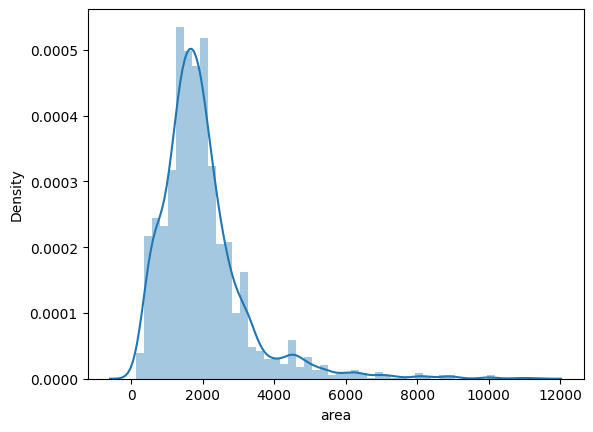

In [134]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

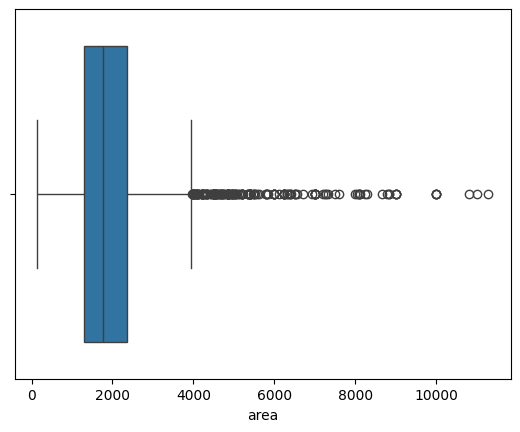

In [135]:
sns.boxplot(x=df['area'])

In [136]:
df['area'].describe()

,area
count,3346.000000
mean,1994.299163
std,1235.289717
min,145.000000
25%,1300.000000
50%,1778.000000
75%,2361.000000
max,11286.000000


### 4. bedRoom

/tmp/ipykernel_2530/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

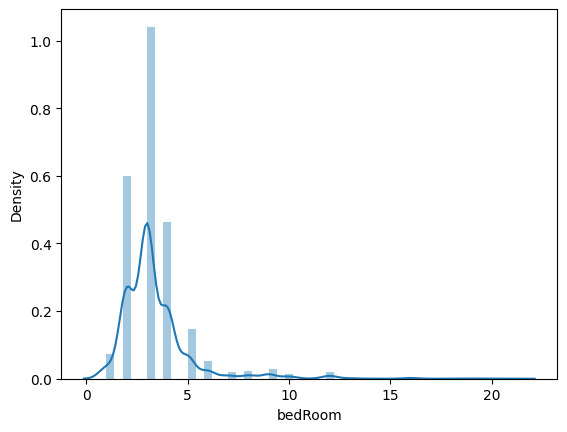

In [137]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

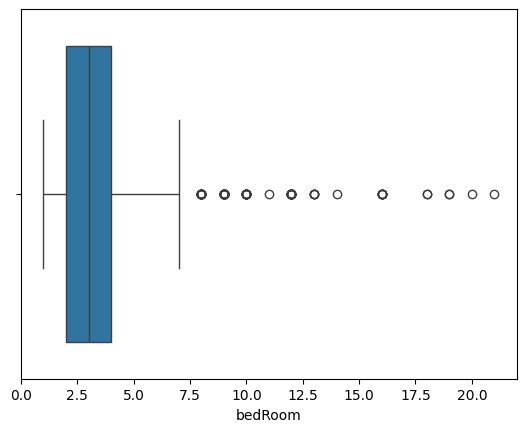

In [138]:
sns.boxplot(x=df['bedRoom'])

In [139]:
df['bedRoom'].describe()

,bedRoom
count,3346.000000
mean,3.403467
std,1.875283
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,21.000000


In [140]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2510,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,2,49
3083,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,2,22
1196,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
692,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
1254,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,2,70
3428,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,2,57
2424,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,1,153
2311,house,independent,sector 40,12.00,38986.0,3078.0,Plot area 342(285.96 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,3078.0,NaN,1,1,1,1,0,1,0
1137,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,0,41
762,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,1,49


In [141]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False).shape

(45, 23)

In [142]:
df = df[df['bedRoom'] <= 10]

In [143]:
df.shape

(3301, 23)

/tmp/ipykernel_2530/1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

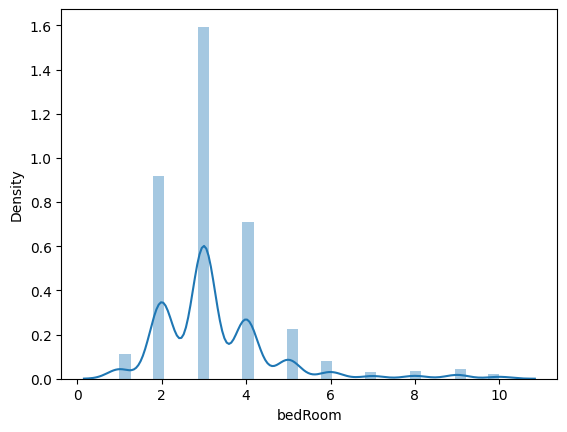

In [144]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

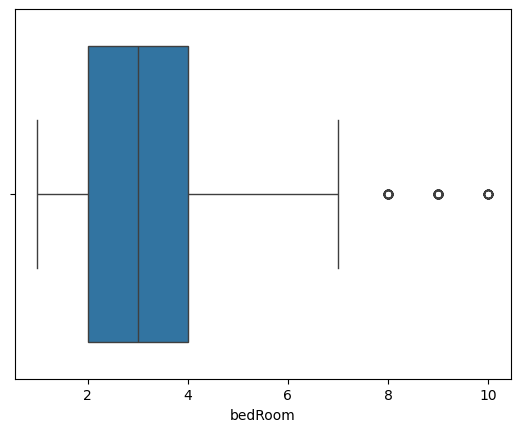

In [145]:
sns.boxplot(x=df['bedRoom'])

In [146]:
df['bedRoom'].describe()

,bedRoom
count,3301.000000
mean,3.263254
std,1.417449
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,10.000000


### 5. bathroom

/tmp/ipykernel_2530/2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

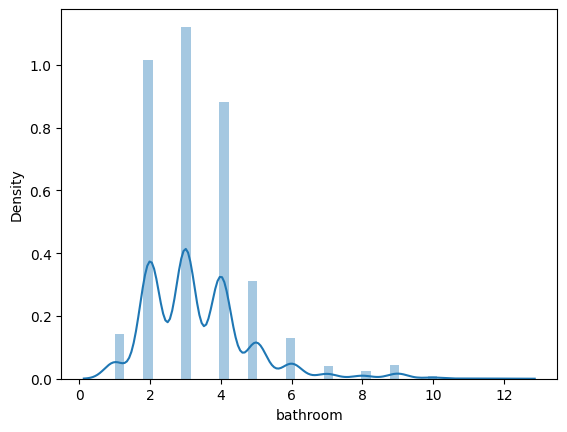

In [147]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

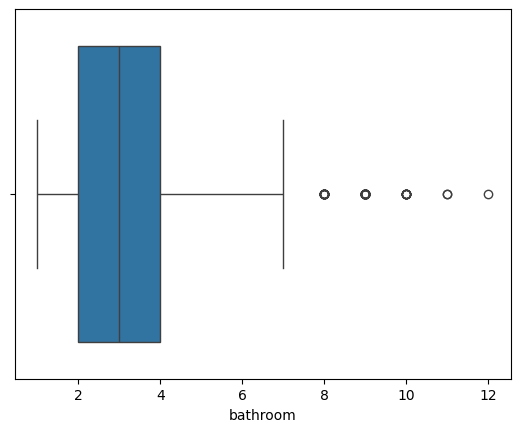

In [148]:
sns.boxplot(x=df['bathroom'])

In [149]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3116,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,1,146
102,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,1,39
226,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,38


### 6. super_built_up_area

/tmp/ipykernel_2530/4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

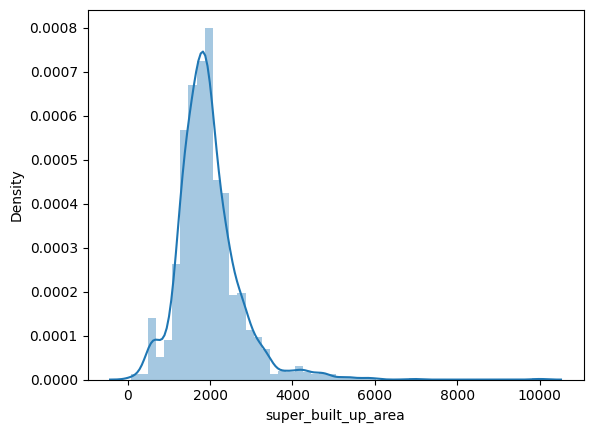

In [150]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

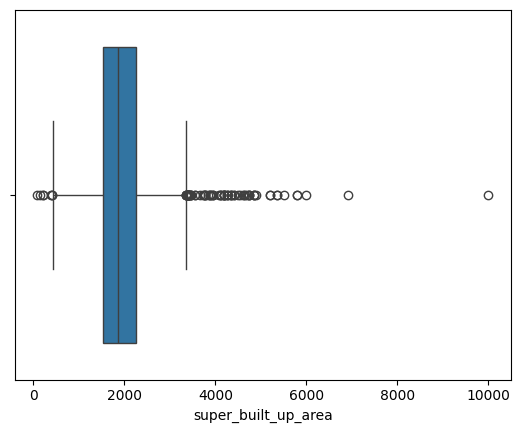

In [151]:
sns.boxplot(x=df['super_built_up_area'])

In [152]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1733.000000
mean,1961.408598
std,760.030660
min,89.000000
25%,1530.000000
50%,1860.000000
75%,2262.000000
max,10000.000000


In [153]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
45,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140
1641,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49


### 7. built_up_area

/tmp/ipykernel_2530/3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

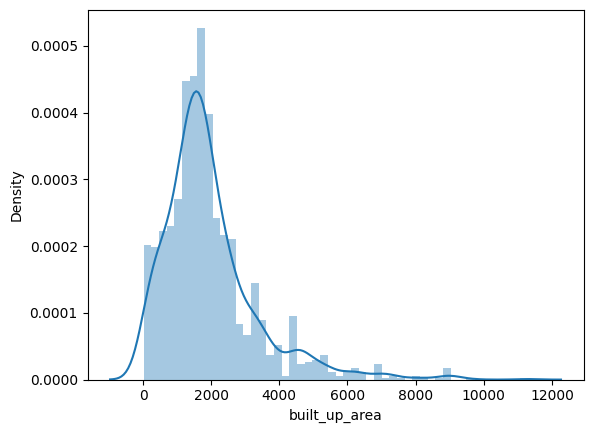

In [154]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

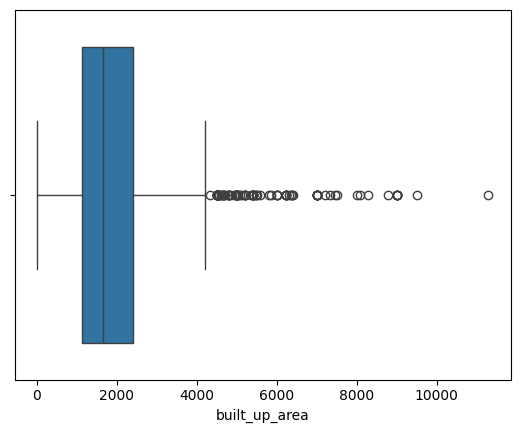

In [155]:
sns.boxplot(x=df['built_up_area'])

In [156]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
509,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,1,42


### 8. carpet_area

/tmp/ipykernel_2530/3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

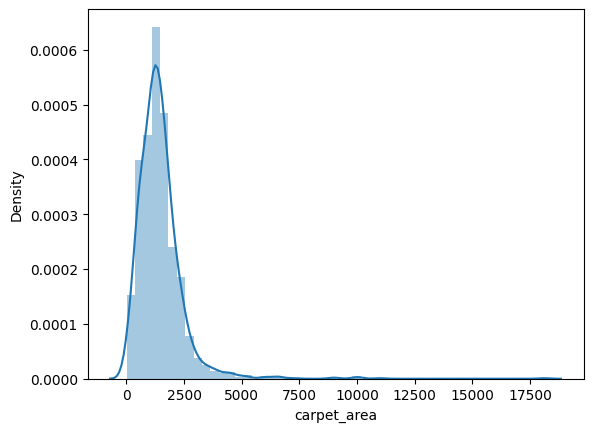

In [157]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

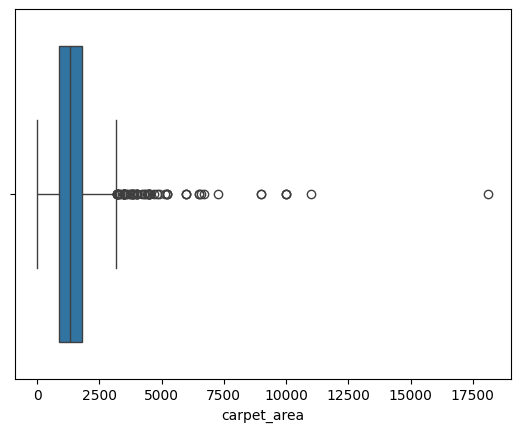

In [158]:
sns.boxplot(x=df['carpet_area'])

In [159]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
533,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
2243,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.0,1,0,0,1,1,1,44


In [160]:
df.loc[2243,'carpet_area'] = 1812

In [161]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
533,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60


### 9. luxury_score

/tmp/ipykernel_2530/3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

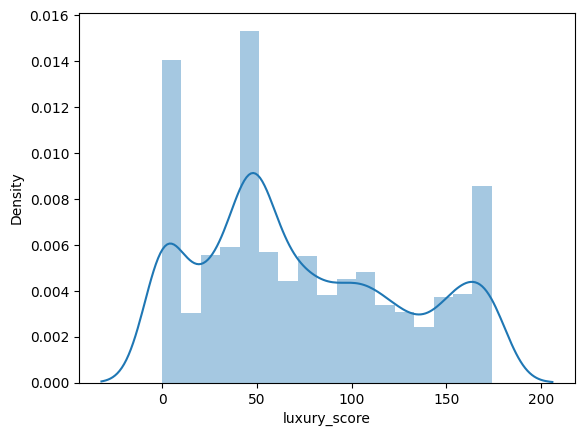

In [162]:
sns.distplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

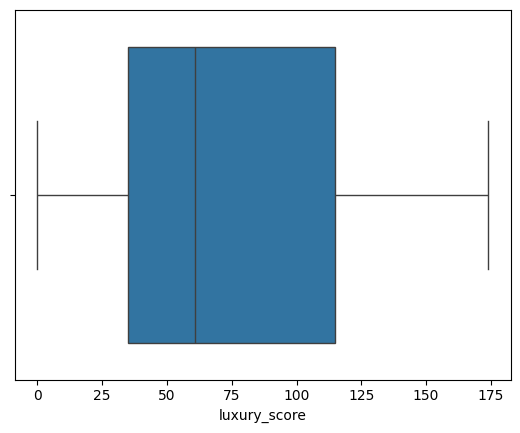

In [163]:
sns.boxplot(x=df['luxury_score'])

In [164]:
df.shape

(3301, 23)

### 10. price_per_sqft

In [165]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [166]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5963.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,10.0,NaN,Relatively New,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,6.0,East,Relatively New,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110


/tmp/ipykernel_2530/2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

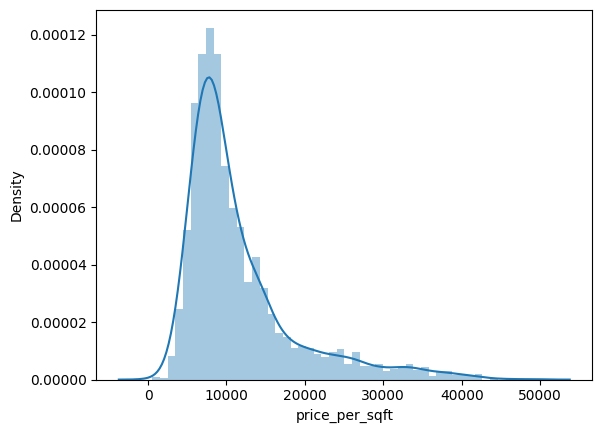

In [167]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

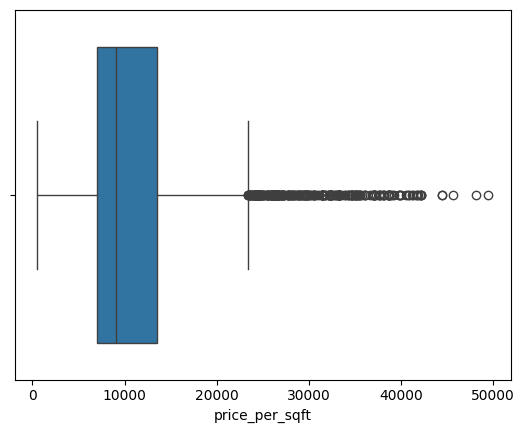

In [168]:
sns.boxplot(x=df['price_per_sqft'])

In [169]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
126,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,0,0
535,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,1,60
1011,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,1,88
1780,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,1,44
1904,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1,1,1,1,0,1,103
2155,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,1,121
2220,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,2,0
3111,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,0,0,1,0,1,7
3451,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97


# Important

In [170]:
# Calculating false data points
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

np.float64(173.34666666666666)

In [171]:
df[(df['area']/df['bedRoom'])<173]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
5,house,independent,sector 105,1.20,13333.0,900.0,Plot area 900(83.61 sq.m.),7,4,1,2.0,South-West,Moderately Old,NaN,900.0,NaN,0,0,0,0,1,0,14
82,house,rattan vihar rajendra park,dwarka expressway,0.85,14167.0,600.0,Plot area 600(55.74 sq.m.),5,5,3+,4.0,NaN,New Property,NaN,600.0,NaN,0,0,0,0,0,0,0
169,house,independent,sector 105,0.60,11111.0,540.0,Plot area 60(50.17 sq.m.),8,4,3,3.0,West,New Property,NaN,540.0,NaN,0,0,0,0,0,0,17
221,house,independent,sector 4,0.80,11852.0,675.0,Plot area 75(62.71 sq.m.),5,3,1,2.0,NaN,Moderately Old,NaN,675.0,NaN,0,0,0,0,0,0,0
237,house,independent,sector 38,2.10,23333.0,900.0,Plot area 100(83.61 sq.m.),7,7,3+,3.0,North-East,Relatively New,NaN,900.0,NaN,1,0,1,1,0,0,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3221,house,independent,sector 55,1.45,26852.0,540.0,Plot area 60(5.57 sq.m.),4,4,3+,4.0,East,Relatively New,NaN,60.0,NaN,0,0,1,0,0,0,70
3286,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0
3380,house,independent,sector 104,0.45,12162.0,370.0,Plot area 370(34.37 sq.m.)Carpet area: 1500 sq...,4,4,2,4.0,North,Moderately Old,NaN,NaN,1500.0,0,0,0,0,0,1,7
3412,house,independent,sector 28,0.75,20833.0,360.0,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately Old,NaN,360.0,NaN,0,0,0,0,0,0,7


In [172]:
# Calculating false data points
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.05)

np.float64(250.0)

In [173]:
df[(df['area']/df['bedRoom'])<250]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
5,house,independent,sector 105,1.20,13333.0,900.0,Plot area 900(83.61 sq.m.),7,4,1,2.0,South-West,Moderately Old,NaN,900.0,NaN,0,0,0,0,1,0,14
7,flat,rof ananda,sector 95,0.38,5901.0,644.0,Carpet area: 644.12 (59.84 sq.m.),3,2,1,2.0,South-East,Relatively New,NaN,NaN,644.111776,0,0,0,1,0,1,66
30,flat,ramsons kshitij,sector 95,0.40,5839.0,685.0,Carpet area: 685 (63.64 sq.m.),3,2,2,6.0,NaN,Undefined,NaN,NaN,685.000000,0,0,0,0,0,0,0
31,flat,signature global solera,sector 107,0.52,8062.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,5.0,East,Relatively New,NaN,NaN,645.000000,0,0,0,0,1,0,15
82,house,rattan vihar rajendra park,dwarka expressway,0.85,14167.0,600.0,Plot area 600(55.74 sq.m.),5,5,3+,4.0,NaN,New Property,NaN,600.0,NaN,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3286,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,NaN,NaN,900.000000,0,0,0,0,0,0,0
3380,house,independent,sector 104,0.45,12162.0,370.0,Plot area 370(34.37 sq.m.)Carpet area: 1500 sq...,4,4,2,4.0,North,Moderately Old,NaN,NaN,1500.000000,0,0,0,0,0,1,7
3412,house,independent,sector 28,0.75,20833.0,360.0,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately Old,NaN,360.0,NaN,0,0,0,0,0,0,7
3432,house,independent,sohna road road,1.20,22305.0,538.0,Plot area 50,4,4,3+,4.0,West,Old Property,NaN,535.0,NaN,0,0,0,0,0,0,8


In [174]:
area_room_ratio = df['area'] / df['bedRoom']

In [175]:
df['area/room'] = area_room_ratio

In [176]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
0,flat,eldeco accolade,sohna road,0.87,5963.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,10.0,NaN,Relatively New,1457.0,NaN,849.00,1,0,0,0,0,0,72,729.500000
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157,521.750000
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120,695.333333
3,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,6.0,East,Relatively New,1900.0,1600.0,1240.04,0,1,0,0,0,1,174,633.333333
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110,563.500000


Extracting the values whose area is less and bedrroms are more

In [177]:
df[(df['area']/df['bedRoom'])<250].to_csv('false_area_values.csv',index=False)

In [178]:
df[(df['area']/df['bedRoom'])<250].sort_values('area/room')

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
3412,house,independent,sector 28,0.75,20833.0,360.0,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately Old,NaN,360.0,NaN,0,0,0,0,0,0,7,51.428571
3009,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,4.0,NaN,New Property,NaN,450.0,NaN,0,0,0,1,0,0,7,64.285714
169,house,independent,sector 105,0.60,11111.0,540.0,Plot area 60(50.17 sq.m.),8,4,3,3.0,West,New Property,NaN,540.0,NaN,0,0,0,0,0,0,17,67.500000
1097,house,ansal,sector 43,1.85,34259.0,540.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,0,53,67.500000
1227,house,independent,sector 6,0.50,13889.0,360.0,Plot area 40(33.45 sq.m.),5,3,3,3.0,NaN,Old Property,NaN,360.0,NaN,0,0,0,0,0,0,0,72.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2392,flat,signature global solera,sector 107,0.28,5680.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,11.0,North,Relatively New,NaN,NaN,489.0,0,0,0,0,0,0,29,246.500000
808,house,independent,sector 47,4.60,26620.0,1728.0,Plot area 192(160.54 sq.m.),7,6,3+,4.0,NaN,Moderately Old,NaN,1728.0,NaN,0,0,0,0,0,2,51,246.857143
1969,flat,pyramid urban homes 2,sector 86,0.42,8485.0,495.0,Carpet area: 501 (46.54 sq.m.),2,2,1,2.0,North-East,New Property,NaN,NaN,501.0,1,1,0,1,1,0,84,247.500000
2835,flat,pyramid urban homes 2,sector 86,0.41,8283.0,495.0,Carpet area: 501 (46.54 sq.m.),2,2,1,7.0,West,New Property,NaN,NaN,501.0,1,1,0,1,1,0,49,247.500000


A conclusion could be that the number of floors are there so the bedroom are balanced for area by the number of floor

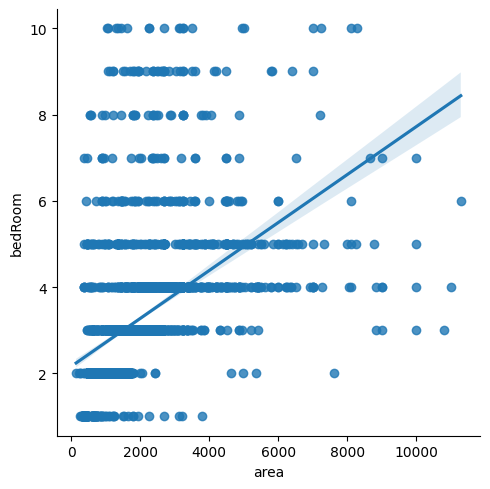

In [179]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [180]:
(df[df['area/room']<250])['bedRoom'].value_counts()

,count
bedRoom,
2,42
3,32
5,28
4,18
6,17
9,15
8,12
7,8
10,8


Removed values whose ratio is less than 100

In [181]:
df=df[df['area/room']>100]

In [182]:
outliers_df=df[(df['area/room']<250)&(df['bedRoom']>3)]

In [184]:
outliers_df['bedRoom']=round(outliers_df['bedRoom']/outliers_df['floorNum'])

/tmp/ipykernel_2530/3359844150.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedRoom']=round(outliers_df['bedRoom']/outliers_df['floorNum'])


In [185]:
df.update(outliers_df)

In [186]:
df['area/room'] = df['area'] / df['bedRoom']

In [187]:
df[(df['area/room']<250)&(df['bedRoom']>4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
794,house,independent,sector 3 phase 2,0.85,9444.0,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,180.000000
1034,house,independent,sector 17,0.32,5664.0,565.0,Built Up area: 565 (52.49 sq.m.),5,1,0,1.0,NaN,Undefined,NaN,565.0,NaN,0,0,0,0,0,0,0,113.000000
1246,house,independent,sector 12,2.50,13889.0,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0,0,0,1,0,0,8,200.000000
1298,house,independent,sector 2,0.98,9074.0,1080.0,Carpet area: 120 (100.34 sq.m.),9,4,3,1.0,South,Undefined,NaN,NaN,120.0,0,0,0,0,0,0,0,120.000000
1333,house,independent,sector 7,1.16,11717.0,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,1.0,North-East,Undefined,NaN,NaN,110.0,0,0,0,0,0,0,0,198.000000
1524,house,independent,manesar,1.10,6173.0,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,0,0,222.750000
1638,house,independent,sector 12,0.65,6500.0,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0,0,0,0,0,0,0,166.666667
1920,house,shivpuri,sector 7,2.80,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1,1,0,1,1,1,0,225.000000
1952,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,Old Property,NaN,67.0,NaN,0,0,0,1,0,0,29,120.600000
2085,house,independent,sector 3 phase 2,1.10,10000.0,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.0,East,Undefined,NaN,1100.0,900.0,0,0,0,0,0,0,0,220.000000


In [188]:
df[(df['area/room']<250)&(df['bedRoom']>4)].shape

(13, 24)

In [189]:
df.shape

(3281, 24)

In [190]:
df=df[~((df['area/room']<250)&(df['bedRoom']>4))]

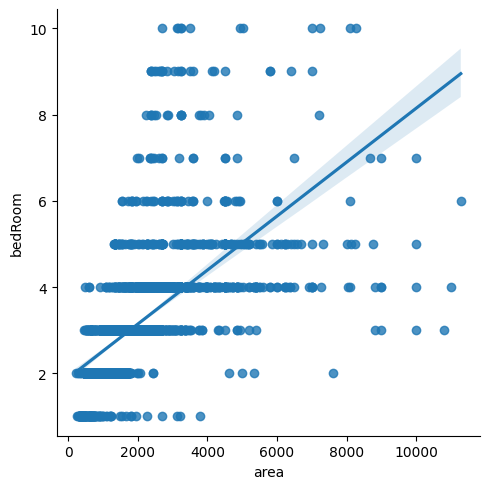

In [191]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [192]:
df.shape

(3268, 24)

In [193]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area/room
0,flat,eldeco accolade,sohna road,0.87,5963.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,10.0,NaN,Relatively New,1457.0,NaN,849.00,1,0,0,0,0,0,72,729.500000
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157,521.750000
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120,695.333333
3,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,6.0,East,Relatively New,1900.0,1600.0,1240.04,0,1,0,0,0,1,174,633.333333
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110,563.500000


In [195]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)